#### Name: 

### <font color='purple'> Comments </font> 

<font color='purple'> no name (-1 pt)</font> 


# PHYS 230 Lab Assignment 17

### Wednesday, April 8, 2026: Chapter 10.1
- Random numbers

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random

## Part 1: Testing random number generators

#### Step 1: Write a function `LCM_random(a,c,m,N,x)` that generates a list of $N$ random numbers using the linear congruent method from a starting seed $x$. 

In [5]:
def LCM_random(a,c,m,N,x):
    rand = []
    for i in range(1,N+1):
        x = (a*x+c) % m
        rand.append(x)
    return rand

#### Step 2: Call on your function from step 1 using the most accepted values of the constants $a,c$, and $m$, and whatever you want to use as the seed. Create an array $r$ of 1000 points. Repeat testing at least three different seeds total. 

In [17]:
r1 = LCM_random(1664525,1013904223,4294967296,1000,3)
r2 = LCM_random(1664525,1013904223,4294967296,1000,7)
r3 = LCM_random(1664525,1013904223,4294967296,1000,10)

#### Step 3: Make a plot (or separate plots may be best) of your arrays using Matplotlib Pyplot (simply feed in a single 1D array) to see how random the data truly is. In a markdown cell, explain any differences you notice when you use different seed values. 

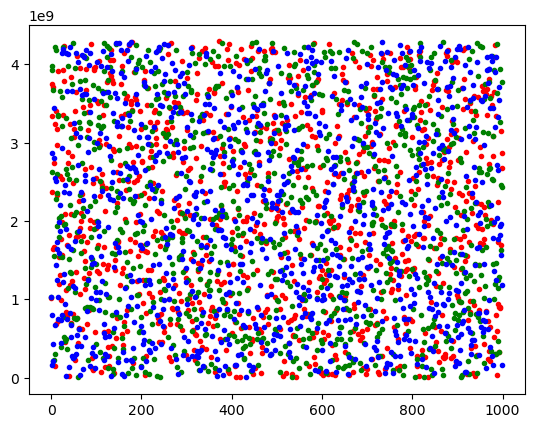

In [29]:
plt.plot(r1, '.r')
plt.plot(r2, '.g')
plt.plot(r3, '.b')
plt.show()

The numbers generally seem random at first glance, but each point is at fixed locations which only change when the seed value is changed.

#### Step 4: Make a plot of successive random numbers for one of your arrays, where your plot points should be ($x,y$) = ($r_i$, $r_{i+1}$). What do you notice about this plot? Do the values truly seem random? 

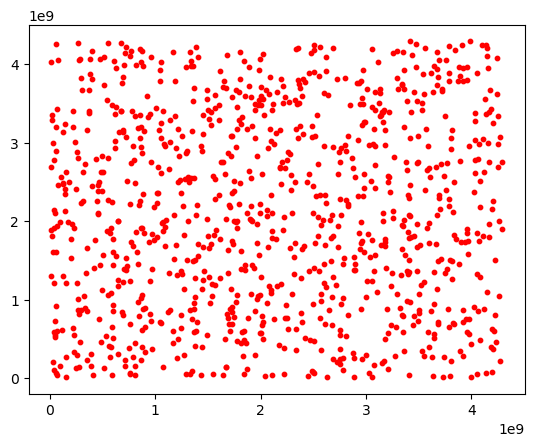

In [6]:
r1k = LCM_random(1664525,1013904223,4294967296,1000,3)
r1kplus1 = LCM_random(1664525,1013904223,4294967296,1001,3)
del r1kplus1[0]

plt.scatter(r1k,r1kplus1, color = 'red', s=10)
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> this is a really weird way of doing this. Could just index a single array instead of creating two from random </font> 


Once again, the values seem random at first glance, until generating it multiple times reveals the deterministic nature of this method.

#### Step 5: Now try an unwise choice of constant for the linear congruent method. Try using $(a,c,m,x) = (57,1,256,10)$ to generate 1000 random values. Make a 1D plot and also the plot (x,y) = ($r_i$, $r_{i+1}$). Explain what you notice about these plots compared to above. 

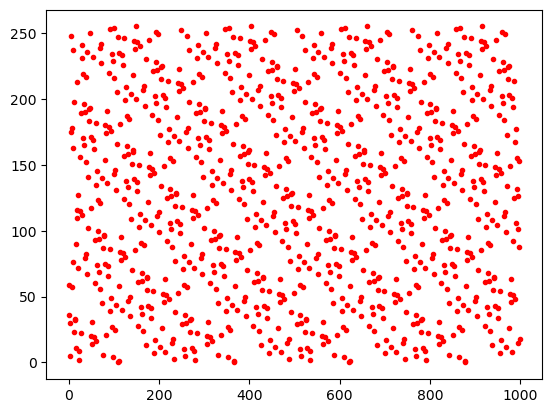

In [35]:
badrand = LCM_random(57,1,256,1000,10)
badrandplus1 = LCM_random(57,1,256,1001,10)
del badrandplus1[0]

plt.plot(badrand, '.r')
plt.show()

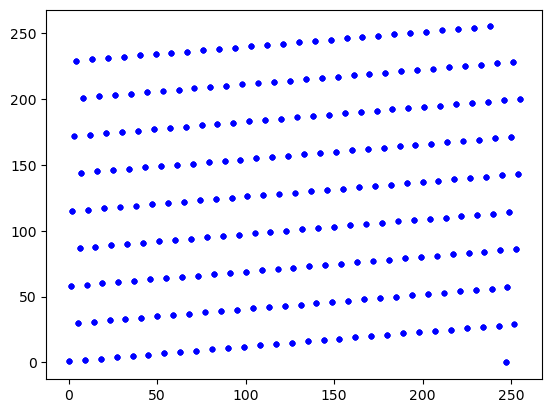

In [36]:
plt.scatter(badrand, badrandplus1, color = 'blue', s=10)
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> comment? </font> 


#### Step 6: Use a built-in random number generator from the `random` package to create an array of 1000 points. Plot the results and compare as done in steps 3 and 4 above. (Don't forget to include a markdown with your comparison.) 

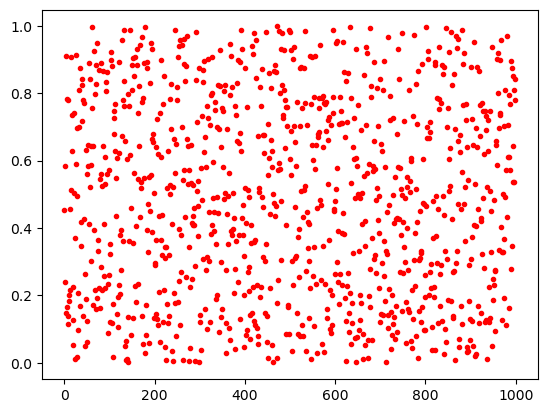

In [56]:
randpy = []
i = 0
while i < 1000:
    randpy.append(random.random())
    i += 1


plt.plot(randpy, '.r')
plt.show()

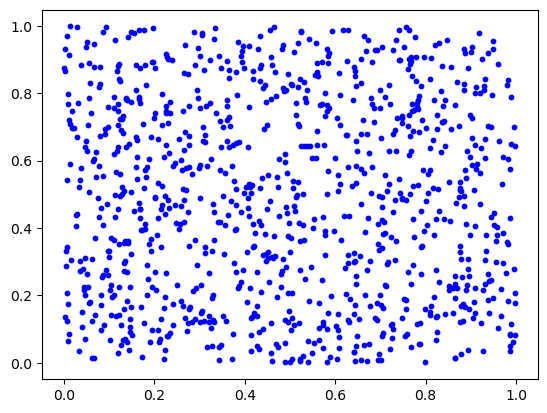

In [58]:
randplus1 = randpy[1:]
randpy = randpy[:-1]
plt.scatter(randpy, randplus1, color = 'blue', s=10)
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'>comment? 
</font> 


## Part 2: Luck & Roulette 
(background information taken from [Wikipedia](https://en.wikipedia.org/wiki/Roulette))

Roulette is a casino game named after the French word meaning little wheel. In the game, a player may choose to place a bet on a single number, various groupings of numbers, the color red or black, whether the number is odd or even, or if the numbers are high (19–36) or low (1–18).

To determine the winning number, a croupier spins a wheel in one direction, then spins a ball in the opposite direction around a tilted circular track running around the outer edge of the wheel. The ball eventually loses momentum, passes through an area of deflectors, and falls onto the wheel and into one of  thirty-eight colored and numbered pockets on the wheel.

As explained above, there are many betting options for Roulette, seen on the roulette table layout below. One of the most common bets is either red or black. 

In this part of the lab, we're going to use a random number generator to determine the odds of winning when a gambling soul chooses red. 


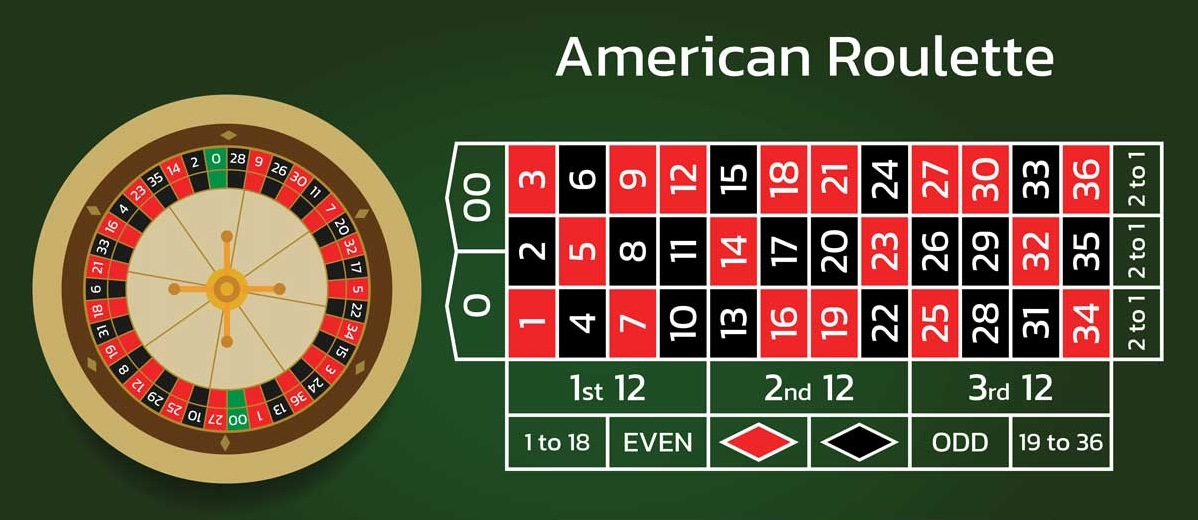

#### Step 1: Create two lists - `red` and `black` - which each contain all of the numbers that belong to those classifications. 

In [81]:
red = [1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36]
black = [2,4,6,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35]

#### Step 2: Develop a *function* to spin the roulette wheel $N$ times. 

In the code it should: 
- create three variables (red_count, black_count, green_count) initially set equal to 0 (Green count will be used to keep track of 0 & 00)
- select a random number between 1 and 38 (37 and 38 are being used to represent 0 and 00 for this game)
- check if that number is in red or black list (or neither) - this would be best done with if, elif, and else
- if the number is red, black, or neither, add one to the corresponding variable from step 2. 

In [64]:
def roulette(N):
    red_count, black_count, green_count = 0, 0, 0
    for n in range(N):
        val = random.randrange(1,38)
        if val in red:
            red_count += 1
        elif val in black:
            black_count += 1
        else:
            green_count += 1
    return red_count,black_count,green_count

#### Step 3: Call on your function to spin the roulette wheel 100, 1000, and 10,000 times. 

For each completion, determine what percentage of the spins were indeed red. 

In [87]:
red100,black100,green100 = roulette(100)
print((red100/(red100+black100+green100))*100, '%')

red1k,black1k,green1k = roulette(1000)
print((red1k/(red1k+black1k+green1k))*100, '%')

red10k,black10k,green10k = roulette(10000)
print((red10k/(red10k+black10k+green10k))*100, '%')

42.0 %
46.5 %
48.58 %


#### Step 4: Vegas pays 1:1 for a red or black winning number, which would suggest you have a 50% chance of getting it right. Is this correct or is Vegas always putting the odds in their favor? Explain briefly. 

The chance of guessing the correct color is not 50%, as the green numbers are also possible outcomes, which drops the probability 

### <font color='purple'> Comments </font> 

<font color='purple'> You haven't put any comments in your code! Good job. Does your data/results suppose this answer? In explaining why, you should reference/include the numbers you got as your results </font> 
